# Synthetic correlated data and uncertainty

This notebook illustrates a central idea in molecular-dynamics analysis:

> A trajectory may contain many saved frames but far fewer statistically independent observations.

We generate synthetic time series with the same mean and variance but different amounts of correlation. We compare their trajectories, distributions, autocorrelation functions, effective sample sizes, uncertainty in the mean, and block-averaging behavior.

## AR(1) model

We generate each trajectory using:

$$
x_t = \rho x_{t-1} + \sqrt{1-\rho^2}\,\epsilon_t
$$

where $\epsilon_t$ is independent standard normal noise.

- $\rho=0$: independent observations
- larger $\rho$: stronger correlation between neighboring observations
- all trajectories have approximately the same mean and variance

For this model, the theoretical autocorrelation is:

$$
\rho(k)=\rho^k
$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## 1. Generate synthetic trajectories

In [2]:
rng = np.random.default_rng(10)

N = 1000

correlations = {
    "Independent": 0.0,
    "Moderate correlation": 0.7,
    "Strong correlation": 0.95,
}


def generate_correlated_data(rho, n, rng):
    """Generate a stationary AR(1) trajectory."""

    values = np.zeros(n)
    values[0] = rng.normal()

    for i in range(1, n):
        noise = rng.normal()
        values[i] = (
            rho * values[i - 1]
            + np.sqrt(1 - rho**2) * noise
        )

    return values


synthetic_data = {
    name: generate_correlated_data(rho, N, rng)
    for name, rho in correlations.items()
}

## 2. Plot the trajectories

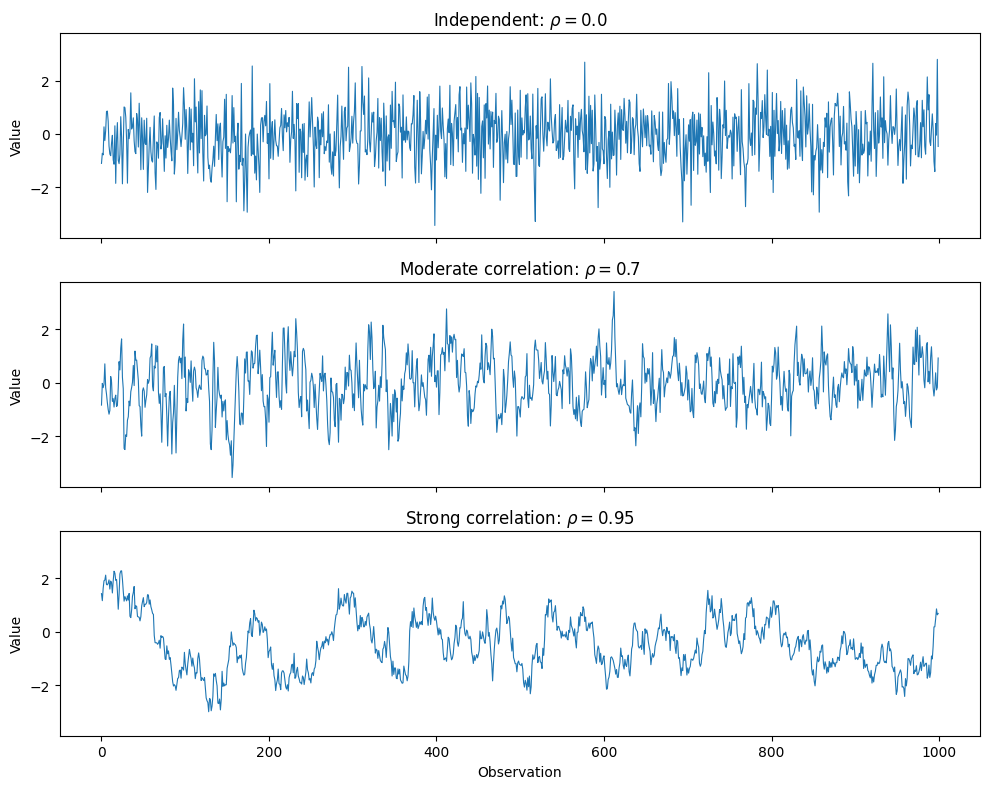

In [3]:
fig, axes = plt.subplots(
    3, 1,
    figsize=(10, 8),
    sharex=True,
    sharey=True,
)

for ax, (name, values) in zip(axes, synthetic_data.items()):
    ax.plot(values, linewidth=0.8)
    ax.set_title(f"{name}: $\\rho={correlations[name]}$")
    ax.set_ylabel("Value")

axes[-1].set_xlabel("Observation")

plt.tight_layout()
plt.show()

### Questions

1. Which trajectory looks the smoothest?
2. Which trajectory remains above or below the mean for the longest time?
3. Do the three trajectories appear to have similar ranges?
4. Does a smooth-looking trajectory necessarily contain less noise?

## 3. Compare the distributions

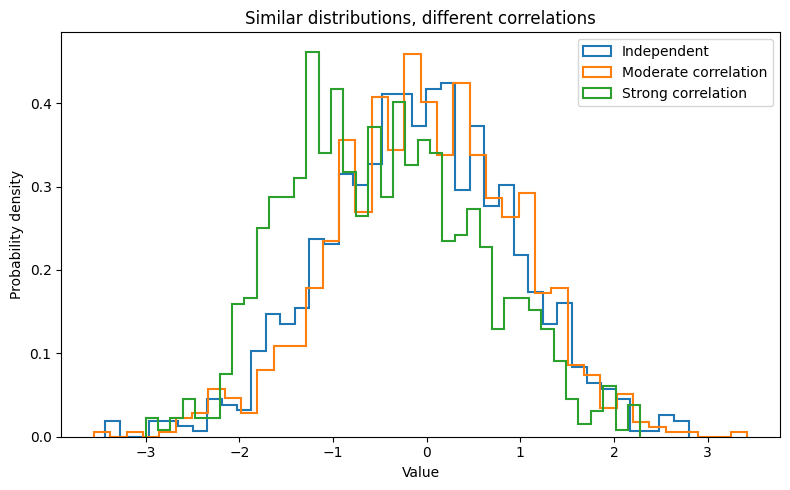

In [4]:
plt.figure(figsize=(8, 5))

for name, values in synthetic_data.items():
    plt.hist(
        values,
        bins=40,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=name,
    )

plt.xlabel("Value")
plt.ylabel("Probability density")
plt.title("Similar distributions, different correlations")
plt.legend()
plt.tight_layout()
plt.show()

### Key point

The datasets have similar one-dimensional distributions. The main difference is the order in which the values appear.

A histogram does not reveal time correlation.

## 4. Calculate the autocorrelation function

For an observable $A$, define the fluctuation from the mean:

$$
\delta A_i = A_i-\bar A
$$

The normalized autocorrelation at lag $k$ is:

$$
\rho(k)
=
\frac{
\frac{1}{N-k}
\sum_{i=0}^{N-k-1}
\delta A_i \delta A_{i+k}
}{
\frac{1}{N}
\sum_{i=0}^{N-1}
\delta A_i^2
}
$$

- $\rho(0)=1$
- slow decay means long memory
- fast decay means rapid decorrelation

In [5]:
def calculate_acf(values, max_lag):
    """Calculate the normalized autocorrelation directly."""

    values = np.asarray(values)
    fluctuations = values - values.mean()
    variance = np.mean(fluctuations**2)

    acf = []

    for lag in range(max_lag + 1):
        earlier = fluctuations[:len(values) - lag]
        later = fluctuations[lag:]

        covariance = np.mean(earlier * later)
        acf.append(covariance / variance)

    return np.array(acf)

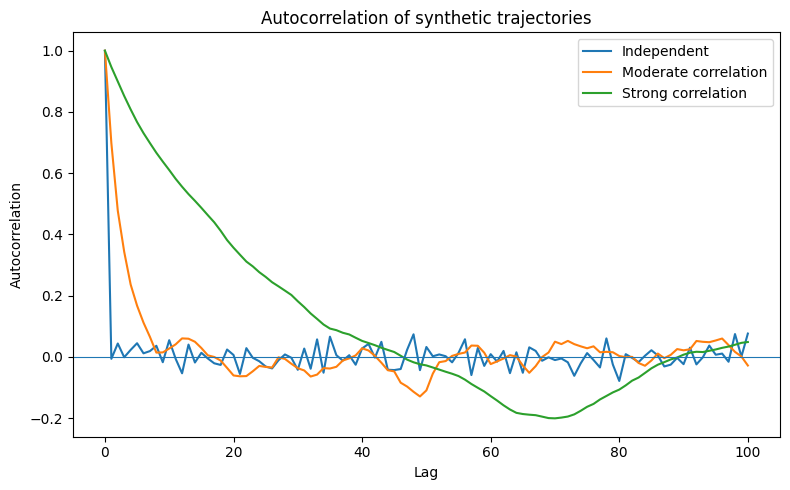

In [6]:
MAX_LAG = 100

plt.figure(figsize=(8, 5))

for name, values in synthetic_data.items():
    acf = calculate_acf(values, MAX_LAG)

    plt.plot(
        np.arange(MAX_LAG + 1),
        acf,
        label=name,
    )

plt.axhline(0, linewidth=0.8)
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.title("Autocorrelation of synthetic trajectories")
plt.legend()
plt.tight_layout()
plt.show()

### Questions

1. Which trajectory loses memory most rapidly?
2. Which trajectory retains memory for the longest time?
3. Why does the strongly correlated trajectory have a slower decay?
4. Why might the long-lag tail become noisy?

## 5. Effective sample size

For an AR(1) process, the statistical inefficiency is approximately:

$$
g=\frac{1+\rho}{1-\rho}
$$

The effective number of independent observations is:

$$
N_{\mathrm{eff}}=\frac{N}{g}
$$

The naive standard error assumes all observations are independent:

$$
\mathrm{SE}_{\mathrm{naive}}=\frac{\sigma}{\sqrt{N}}
$$

The correlation-corrected standard error is:

$$
\mathrm{SE}_{\mathrm{corr}}
=
\frac{\sigma}{\sqrt{N_{\mathrm{eff}}}}
$$

In [7]:
for name, rho in correlations.items():
    g = (1 + rho) / (1 - rho)
    effective_samples = N / g

    values = synthetic_data[name]
    standard_deviation = values.std(ddof=1)

    naive_se = standard_deviation / np.sqrt(N)
    corrected_se = standard_deviation / np.sqrt(effective_samples)

    print(f"\n{name}")
    print("-" * 40)
    print(f"Correlation rho:           {rho}")
    print(f"Stored observations:       {N}")
    print(f"Statistical inefficiency:  {g:.2f}")
    print(f"Effective observations:    {effective_samples:.1f}")
    print(f"Naive standard error:      {naive_se:.4f}")
    print(f"Corrected standard error:  {corrected_se:.4f}")


Independent
----------------------------------------
Correlation rho:           0.0
Stored observations:       1000
Statistical inefficiency:  1.00
Effective observations:    1000.0
Naive standard error:      0.0315
Corrected standard error:  0.0315

Moderate correlation
----------------------------------------
Correlation rho:           0.7
Stored observations:       1000
Statistical inefficiency:  5.67
Effective observations:    176.5
Naive standard error:      0.0308
Corrected standard error:  0.0732

Strong correlation
----------------------------------------
Correlation rho:           0.95
Stored observations:       1000
Statistical inefficiency:  39.00
Effective observations:    25.6
Naive standard error:      0.0316
Corrected standard error:  0.1976


### Key point

The strongly correlated trajectory contains 1000 stored values, but only a much smaller number of effectively independent observations.

## 6. Repeated trajectories

A direct way to see the effect of correlation is to generate many independent trajectories and compare their estimated means.

If observations are strongly correlated, the estimated mean varies more from one trajectory to another.

In [8]:
N_REPLICATES = 1000

replicate_means = {}

for name, rho in correlations.items():
    means = []

    for repeat in range(N_REPLICATES):
        values = generate_correlated_data(
            rho,
            N,
            rng,
        )
        means.append(values.mean())

    replicate_means[name] = np.array(means)

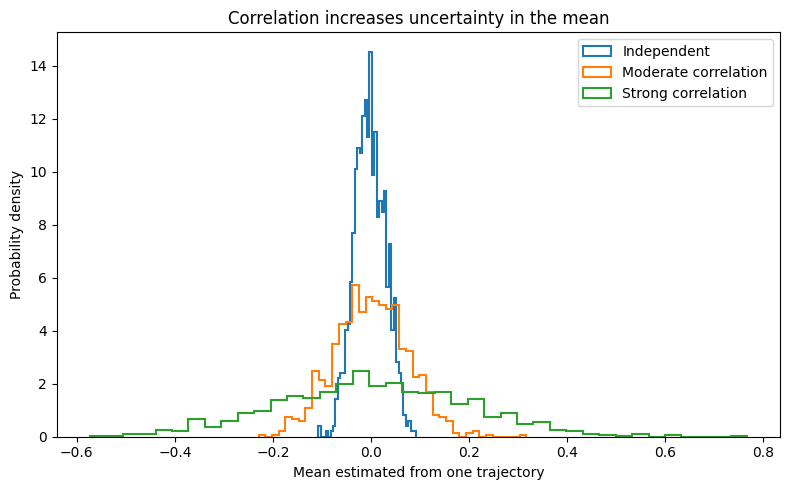

In [9]:
plt.figure(figsize=(8, 5))

for name, means in replicate_means.items():
    plt.hist(
        means,
        bins=40,
        density=True,
        histtype="step",
        linewidth=1.5,
        label=name,
    )

plt.xlabel("Mean estimated from one trajectory")
plt.ylabel("Probability density")
plt.title("Correlation increases uncertainty in the mean")
plt.legend()
plt.tight_layout()
plt.show()

### Questions

1. Which set of trajectory means has the narrowest distribution?
2. Which has the broadest distribution?
3. Why do all three have the same underlying mean but different uncertainty?
4. How does this connect to molecular-dynamics trajectories?

**How does this connect to molecular-dynamics trajectories?**

MD trajectories also contain correlated frames. Saving more frames does not necessarily provide more independent information. Slow molecular motions can keep observables correlated for long times, so two trajectories with the same number of stored frames can have very different uncertainties in their estimated averages.

The repeated independent runs make this visible directly: the spread of trajectory means is the actual run-to-run uncertainty in the estimated mean.

## 7. Block averaging

In block averaging, the trajectory is divided into nonoverlapping blocks. We calculate a mean for each block and estimate the standard error from the variation among block means.

At very small block sizes, neighboring blocks remain correlated and the error is underestimated. As block size increases, the estimated error should approach a plateau.

In [10]:
def block_standard_error(values, block_size):
    """Estimate the standard error from nonoverlapping block means."""

    n_blocks = len(values) // block_size

    if n_blocks < 4:
        return np.nan

    trimmed = values[:n_blocks * block_size]

    block_means = trimmed.reshape(
        n_blocks,
        block_size,
    ).mean(axis=1)

    return (
        block_means.std(ddof=1)
        / np.sqrt(n_blocks)
    )

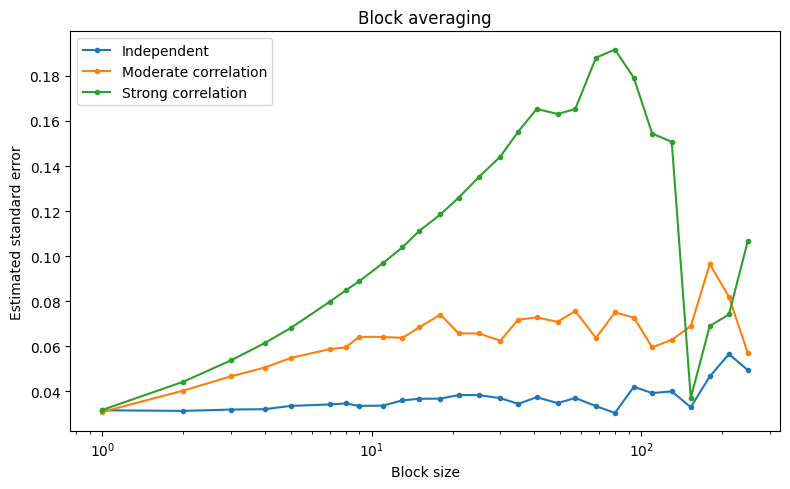

In [11]:
plt.figure(figsize=(8, 5))

for name, values in synthetic_data.items():
    largest_block = len(values) // 4

    block_sizes = np.unique(
        np.logspace(
            0,
            np.log10(largest_block),
            35,
        ).astype(int)
    )

    errors = [
        block_standard_error(values, block_size)
        for block_size in block_sizes
    ]

    plt.plot(
        block_sizes,
        errors,
        marker="o",
        markersize=3,
        label=name,
    )

plt.xscale("log")
plt.xlabel("Block size")
plt.ylabel("Estimated standard error")
plt.title("Block averaging")
plt.legend()
plt.tight_layout()
plt.show()

### Questions

1. Why is the estimated error too small at small block sizes?
2. Which trajectory requires the largest blocks before approaching a plateau?
3. Why does the estimate become noisy at very large block sizes?
4. How does the block-averaging result compare with the effective-sample-size estimate?

It is interesting that we see no plateau for the $\rho$=0.95 case.

To see a clean block-averaging plateau, the block size must be large enough that block means are nearly independent, but you also need many blocks left to estimate the variance of those block means reliably. Those two requirements conflict here:

Small blocks: still correlated, so error is underestimated.
Large blocks: more independent, but too few blocks remain.
Very large blocks: estimate becomes noisy before a clear plateau develops.

So failure to reach a plateau usually means the trajectory is not long enough relative to the correlation time.


**Not seeing a plateau is itself useful information: the data may be insufficient for a stable uncertainty estimate.**

## Effect of trajectory length on block averaging

For strongly correlated data, a short trajectory may not show a clear plateau in the block-averaged standard error.

Increasing the trajectory length provides:

* more independent information
* more blocks at a given block size
* a less noisy estimate of the variation among block means
* a clearer plateau in the estimated standard error

Here, we keep the correlation fixed at (\rho=0.95) and increase the total number of observations (N).


## Effect of trajectory length on block averaging

For strongly correlated data, a short trajectory may not show a clear plateau in the block-averaged standard error.

Increasing the trajectory length provides:

* more independent information
* more blocks at a given block size
* a less noisy estimate of the variation among block means
* a clearer plateau in the estimated standard error

Here, we keep the correlation fixed at (\rho=0.95) and increase the total number of observations (N).


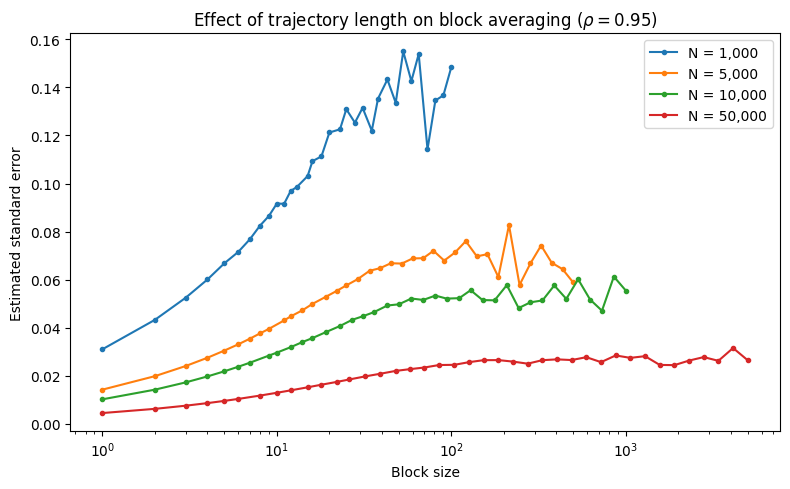

In [14]:
# Effect of trajectory length on block averaging
# Strongly correlated case only: rho = 0.95

rho = 0.95

trajectory_lengths = [
    1_000,
    5_000,
    10_000,
    50_000
]

plt.figure(figsize=(8, 5))

for n in trajectory_lengths:

    # Generate a new trajectory of length n
    values = generate_correlated_data(
        rho,
        n,
        rng
    )

    # Require at least 10 blocks at the largest block size
    largest_block = n // 10

    block_sizes = np.unique(
        np.logspace(
            0,
            np.log10(largest_block),
            45
        ).astype(int)
    )

    block_errors = []

    for block_size in block_sizes:
        error = block_standard_error(
            values,
            block_size
        )

        block_errors.append(error)

    plt.plot(
        block_sizes,
        block_errors,
        marker="o",
        markersize=3,
        label=f"N = {n:,}"
    )

plt.xscale("log")

plt.xlabel("Block size")
plt.ylabel("Estimated standard error")
plt.title(
    r"Effect of trajectory length on block averaging "
    r"($\rho=0.95$)"
)

plt.legend()
plt.tight_layout()
plt.show()

## Main conclusion

All three synthetic datasets have approximately the same mean and variance, but their uncertainties differ because their observations have different amounts of correlation.

> **The number of saved observations is not the same as the number of independent observations.**

## EXTRA NOTES

## Statistical inefficiency for an AR(1) process

For an AR(1) process,

$$x_t=\rho x_{t-1}+\epsilon_t$$

the autocorrelation at lag (k) is

$$\rho(k)=\rho^k$$

The statistical inefficiency is defined as

$$g=1+2\sum_{k=1}^{\infty}\rho(k)$$

Substituting the AR(1) autocorrelation gives

$$g=1+2\sum_{k=1}^{\infty}\rho^k$$

The sum is a geometric series:

$$\sum_{k=1}^{\infty}\rho^k=\frac{\rho}{1-\rho}, \qquad |\rho|<1$$

Therefore,

$$g=1+2\frac{\rho}{1-\rho}$$

which simplifies to

$$g=\frac{1+\rho}{1-\rho}$$

The effective number of independent observations is

$$N_{\mathrm{eff}}=\frac{N}{g}=N\frac{1-\rho}{1+\rho}$$

For example, when (\rho=0.95),

$$g=\frac{1+0.95}{1-0.95}=39$$

Thus, for (N=1000),

$$N_{\mathrm{eff}}=\frac{1000}{39}\approx 26$$

So 1000 stored observations contain roughly 26 independent observations.

Here, (g) is the **statistical inefficiency**. The statistical efficiency is its inverse:

$$\mathrm{efficiency}=\frac{1}{g}$$


## Why does the standard error decrease with sample size?

Suppose we have (N) independent observations:

$$X_1,X_2,\ldots,X_N$$

Each observation has mean $(\mu)$ and variance $(\sigma^2)$.

The sample mean is

$$\bar{X}=\frac{1}{N}\sum_{i=1}^{N}X_i$$

We want to know how much $(\bar{X})$ would vary if we repeated the entire experiment many times.

The variance of a scaled quantity follows

$$\mathrm{Var}(aX)=a^2\mathrm{Var}(X)$$

Therefore,

$$\mathrm{Var}(\bar{X})=\frac{1}{N^2}\mathrm{Var}\left(\sum_{i=1}^{N}X_i\right)$$

For independent observations, variances add:

$$\mathrm{Var}\left(\sum_{i=1}^{N}X_i\right)=N\sigma^2$$

Thus,

$$\mathrm{Var}(\bar{X})=\frac{1}{N^2}N\sigma^2=\frac{\sigma^2}{N}$$

The standard error is the standard deviation of the sample mean:

$$\mathrm{SE}(\bar{X})=\sqrt{\mathrm{Var}(\bar{X})}$$

Therefore,

$$\mathrm{SE}(\bar{X})=\frac{\sigma}{\sqrt{N}}$$

In practice, $(\sigma)$ is usually unknown, so we use the sample standard deviation $(s)$:

$$ \mathrm{SE}(\bar{X})\approx\frac{s}{\sqrt{N}}$$

We therefore divide the **variance of the mean** by (N), but divide the **standard deviation** by $(\sqrt{N})$.

### Intuition

Each independent observation contains random fluctuations. When observations are averaged, positive and negative fluctuations partly cancel.

Increasing the number of independent observations makes the mean more precise. However, the improvement follows $(1/\sqrt{N})$, not $(1/N)$.

For example, increasing the sample size by a factor of four reduces the standard error by a factor of two:

$$\mathrm{SE}(4N)=\frac{\sigma}{\sqrt{4N}}=\frac{1}{2}\mathrm{SE}(N)$$


### Correlated molecular dynamics data

For correlated observations, covariance terms must also be included:

$$\mathrm{Var}\left(\sum_i X_i\right)=\sum_i\mathrm{Var}(X_i)+2\sum_{i<j}\mathrm{Cov}(X_i,X_j)$$

Positive correlations increase the variance of the mean. The stored number of frames (N) therefore overstates the amount of independent information.

We account for this using the effective sample size:

$$N_{\mathrm{eff}}=\frac{N}{g}$$

where (g) is the statistical inefficiency.

The correlation-corrected standard error is

$$\mathrm{SE}(\bar{X})=\frac{s}{\sqrt{N_{\mathrm{eff}}}}$$

The central idea is:

> Averaging reduces uncertainty according to the number of independent observations, not simply the number of stored frames.
